In [2]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [3]:
X,_=make_blobs(n_samples=5000,centers=5,random_state=10)
X

array([[  6.17306585, -10.25446247],
       [ -8.13981972,   4.45135687],
       [  2.71307241,   4.32686739],
       ...,
       [ -6.91896111,   4.29323728],
       [ -3.95595105,   4.23150467],
       [  0.91461712,  -7.45569288]], shape=(5000, 2))

In [4]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

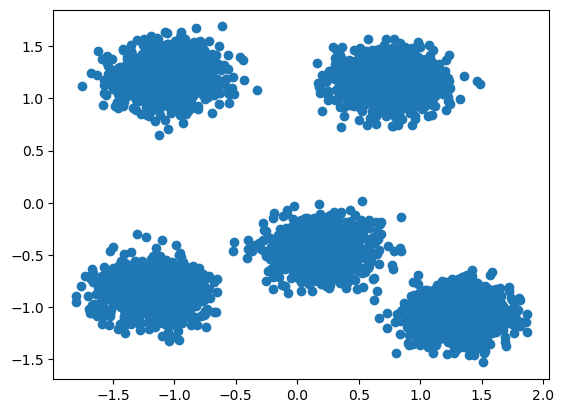

In [5]:
import matplotlib.pyplot as plt
plt.scatter(X_scaled[:,0],X_scaled[:,1])

In [6]:
kmeans=KMeans(n_clusters=5)
kmeans.fit(X_scaled)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


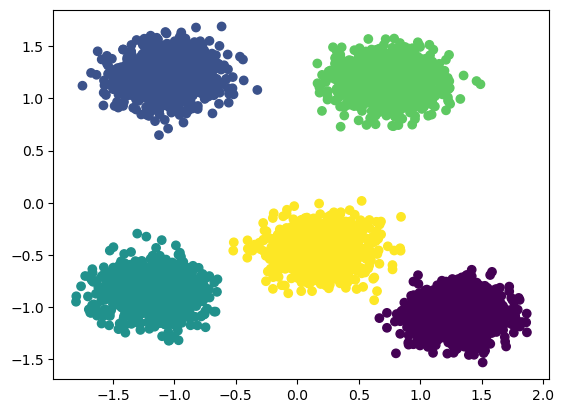

In [7]:
plt.scatter(X_scaled[:,0],X_scaled[:,1], c=kmeans.labels_)

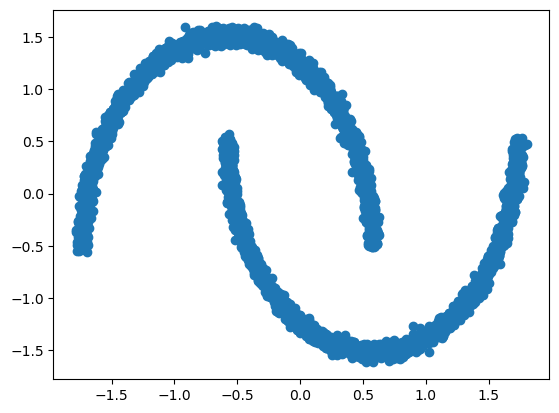

In [8]:
from sklearn.datasets import make_moons
X,_=make_moons(n_samples=5000, noise=0.02)
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
plt.scatter(X_scaled[:,0],X_scaled[:,1] )

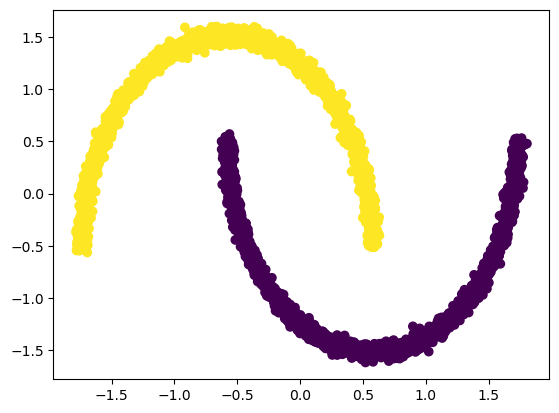

In [9]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
X,_=make_moons(n_samples=5000, noise=0.02)
scaler=StandardScaler()
dbscan=DBSCAN(eps=0.2)
dbscan.fit(X_scaled)
plt.scatter(X_scaled[:,0],X_scaled[:,1], c=dbscan.labels_ )



In [10]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


In [11]:
X,y=fetch_openml('mnist_784', return_X_y=True)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [12]:
pca=PCA(n_components=10)
X_train_reduced=pca.fit_transform(X_train)
X_test_reduced=pca.transform(X_test)
X_train.shape

(56000, 784)

In [13]:
clf=LogisticRegression(max_iter=100)
clf.fit(X_train_reduced,y_train)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
clf.score(X_test_reduced,y_test)

0.8006428571428571

In [18]:
pca.explained_variance_ratio_

array([0.09747258, 0.07171133, 0.06165926, 0.05418112, 0.04859922,
       0.04303424, 0.03290366, 0.02885822, 0.02752979, 0.02343808])

In [20]:
clf.score(X_test_reduced,y_test)

0.8006428571428571

In [31]:
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score
y_pred=clf.predict(X_test_reduced)
precision=precision_score(y_test,y_pred, average='macro')
precision


0.7976041473133343